# Dynamic Mode Decomposition for Pendulum Video Motion

This notebook applies Dynamic Mode Decomposition to a synthetic pendulum video sequence (high-dimensional pixel observations generated by low-dimensional periodic motion). The goal is to use a controlled visual dynamical system to study DMD reconstruction, background/foreground separation, frame forecasting, and bob-centroid forecasting.

## Dynamic Mode Decomposition (DMD)

Dynamic Mode Decomposition (DMD) is a data-driven method for approximating the time evolution of a system from observed snapshots. The main idea is to learn a linear time-advance model from data:

$$
\vec{x}_{k+1} \approx A\vec{x}_k
$$

where $\vec{x}_k$ is the observed state of the system at time step $k$, and $A$ is an unknown linear operator that advances the system one time step forward.

DMD is especially useful when the observed data is high-dimensional but appears to be driven by lower-dimensional structure. Common examples include fluid dynamics, video processing, oscillatory systems, and other spatiotemporal datasets. In this notebook, the state $\vec{x}_k$ will represent a video frame from a synthetic pendulum sequence. Each frame is flattened into a vector, so the full video becomes a sequence of high-dimensional state vectors.

The goal is not just to compress the video. The goal is to learn dominant spatial-temporal patterns, reconstruct observed motion, and forecast short-horizon future states.

This overview follows the standard DMD formulation described in *Data-Driven Science and Engineering: Machine Learning, Dynamical Systems, and Control* by Brunton and Kutz.

## Continuous-Time Motivation

A general dynamical system can be written as

$$
\frac{d\vec{x}}{dt} = f(\vec{x}, t, \vec{\mu})
$$

where $\vec{x}$ is the state vector, $t$ is time, $\vec{\mu}$ represents possible system parameters, and $f$ describes how the state changes.

For many real systems, $f$ may be nonlinear, unknown, or difficult to model from first principles. DMD takes a data-driven approach: instead of deriving the exact governing equations, it attempts to approximate the observed evolution using a linear model.

A simplified continuous-time linear system has the form

$$
\frac{d\vec{x}}{dt} = A\vec{x}
$$

with solution

$$
\vec{x}(t) = e^{At}\vec{x}(0)
$$

If $A$ is diagonalizable, then

$$
A = V\Lambda V^{-1}
$$

where the columns of $V$ are eigenvectors and the diagonal entries of $\Lambda$ are eigenvalues. Substituting this into the solution gives

$$
\vec{x}(t)
=
V e^{\Lambda t} V^{-1}\vec{x}(0)
$$

or equivalently,

$$
\vec{x}(t)
=
\sum_{i=1}^{n} b_i \vec{v}_i e^{\lambda_i t}.
$$

This expression shows why eigenvalues and eigenvectors are important. The eigenvectors describe spatial directions or modes, while the eigenvalues describe how those modes evolve through time. Some modes may decay, some may grow, and complex-valued eigenvalues can represent oscillatory behavior.

DMD uses this same idea, but estimates the modes and eigenvalues directly from data.

## Discrete-Time Snapshot Model

In practice, the data is observed at discrete time steps. For a video, each frame is one snapshot in time.

Let

$$
X =
\begin{bmatrix}
| & | &  & | \\
\vec{x}_1 & \vec{x}_2 & \cdots & \vec{x}_{m-1} \\
| & | &  & |
\end{bmatrix}
$$

and

$$
X' =
\begin{bmatrix}
| & | &  & | \\
\vec{x}_2 & \vec{x}_3 & \cdots & \vec{x}_{m} \\
| & | &  & |
\end{bmatrix}.
$$

The columns of $X$ contain the earlier snapshots, and the columns of $X'$ contain the same snapshots shifted forward by one time step.

DMD assumes there is an approximate linear operator $A$ such that

$$
X' \approx AX.
$$

The least-squares solution is

$$
A = X'X^{\dagger},
$$

where $X^{\dagger}$ is the Moore-Penrose pseudoinverse of $X$.

This equation is conceptually simple, but directly forming $A$ is usually impractical for high-dimensional data. For example, if each video frame has $n$ pixels, then $A$ has shape $n \times n$. Even for modest image sizes, this matrix can be extremely large.

DMD avoids forming the full matrix $A$ by projecting the dynamics into a lower-dimensional subspace using the Singular Value Decomposition (SVD).

## Low-Rank Approximation

The key assumption is that the high-dimensional snapshot data has useful low-rank structure. That is, most of the important variation in the data can be represented using only $r$ dominant directions.

Compute the reduced SVD of $X$:

$$
X \approx U_r \Sigma_r V_r^*
$$

where:

- $U_r$ contains the first $r$ left singular vectors,
- $\Sigma_r$ contains the first $r$ singular values,
- $V_r$ contains the first $r$ right singular vectors,
- $r$ is the chosen truncation rank.

The columns of $U_r$ define a low-dimensional subspace that captures the dominant structure in the snapshot matrix.

The choice of $r$ is important. A small value may discard meaningful dynamics, while a large value may retain noise or make the model less stable. A common first approach is to inspect the singular values and choose a cutoff where the values begin to decay sharply.

## Reduced Linear Operator

Instead of working with the full operator $A$, DMD constructs a reduced operator

$$
\tilde{A} = U_r^* A U_r.
$$

Using the snapshot matrices and SVD factors, this can be computed without explicitly forming $A$:

$$
\tilde{A}
=
U_r^* X' V_r \Sigma_r^{-1}.
$$

The matrix $\tilde{A}$ has shape $r \times r$, making it much smaller and easier to analyze than the full $n \times n$ operator.

## Eigen-Decomposition

Next, compute the eigenvalues and eigenvectors of $\tilde{A}$:

$$
\tilde{A}W = W\Lambda.
$$

The diagonal entries of $\Lambda$ are the DMD eigenvalues. These eigenvalues describe the temporal behavior of the learned modes.

For discrete-time DMD:

- $|\lambda_i| < 1$ suggests a decaying mode,
- $|\lambda_i| > 1$ suggests a growing mode,
- $|\lambda_i| \approx 1$ suggests a persistent mode,
- complex conjugate eigenvalues often correspond to oscillatory behavior.

This is especially relevant for a pendulum, since pendulum motion is periodic. DMD should be able to represent the dominant swinging motion using oscillatory modes.

## DMD Modes

The DMD modes map the reduced eigenvectors back into the original high-dimensional state space.

The exact DMD modes are computed as

$$
\Phi = X' V_r \Sigma_r^{-1} W.
$$

The columns of $\Phi$ are the DMD modes. Each mode represents a spatial pattern, and each corresponding eigenvalue describes how that pattern evolves in time.

For video data, a DMD mode can be reshaped back into image form. This makes the modes visually interpretable: they can reveal background structure, moving foreground structure, or oscillatory components of the motion.

## Reconstruction and Forecasting

Once the DMD modes and eigenvalues are known, snapshots can be reconstructed or forecasted using

$$
\vec{x}_k \approx \Phi \Lambda^{k-1} \vec{b}
$$

where $\vec{b}$ contains the modal amplitudes for the initial condition.

The amplitudes are commonly computed from the first snapshot:

$$
\vec{b} = \Phi^{\dagger}\vec{x}_1.
$$

Then the reconstructed sequence is

$$
\vec{x}_k
\approx
\sum_{i=1}^{r}
\phi_i \lambda_i^{k-1} b_i.
$$

This formula can be used for two related tasks:

1. **Reconstruction**: approximate frames that were included in the fitting window.
2. **Forecasting**: extrapolate beyond the fitting window to predict future frames.

For forecasting from a more recent observed state $\vec{x}_j$, the amplitudes can be recomputed as

$$
\vec{b}_j = \Phi^{\dagger}\vec{x}_j
$$

and future states can be predicted by

$$
\vec{x}_{j+s}
\approx
\Phi \Lambda^s \vec{b}_j.
$$

In this notebook, DMD will be applied to a synthetic pendulum video sequence. The synthetic setup gives us known ground-truth bob coordinates and known future frames, so the results can be evaluated visually and quantitatively.

The main questions are:

1. Can DMD reconstruct the observed pendulum motion?
2. Can DMD forecast short-horizon future frames?
3. Can the predicted motion be compared against the true pendulum bob trajectory?
4. How does the choice of rank $r$ affect reconstruction and forecasting quality?

## Experiment Outline

This notebook applies Dynamic Mode Decomposition to a synthetic pendulum video sequence.

The goal is to use a controlled dynamical system where the true motion is known. A pendulum is a good test case for DMD because its motion is smooth, periodic, and low-dimensional, while the video frames themselves are high-dimensional pixel observations.

The experiment has four main stages:

1. **Generate a synthetic pendulum sequence**

   A script generates RGB video frames of a pendulum swinging from a fixed pivot. Each frame contains a pendulum arm and circular bob. The generator also saves ground-truth information, including the pendulum angle and the true bob-center coordinates for every frame.

   This gives us both:

   - high-dimensional image data for DMD,
   - known ground truth for evaluating motion and forecasting.

2. **Build the DMD snapshot matrices**

   Each video frame is converted to grayscale, flattened into a vector, and stacked into a snapshot matrix.

   If each frame has height $h$ and width $w$, then each state vector has dimension

   $$
   n = h \cdot w.
   $$

   The snapshot matrices are formed as

   $$
   X = [\vec{x}_1 \; \vec{x}_2 \; \cdots \; \vec{x}_{m-1}]
   $$

   and

   $$
   X' = [\vec{x}_2 \; \vec{x}_3 \; \cdots \; \vec{x}_{m}].
   $$

   DMD then estimates an approximate linear time-advance relationship:

   $$
   X' \approx AX.
   $$

3. **Fit DMD and reconstruct observed motion**

   DMD is fit using a rank-$r$ truncated SVD of the snapshot matrix. The resulting DMD modes and eigenvalues describe spatial patterns and their temporal evolution.

   The first evaluation is reconstruction: can DMD reproduce the pendulum frames used during fitting?

   Reconstruction quality can be inspected visually and measured using frame-level error metrics such as mean squared error.

4. **Forecast future frames**

   After fitting DMD on an initial window of frames, the model is used to extrapolate beyond the fitting window.

   This gives a direct test of DMD as a forecasting method:

   $$
   \vec{x}_{k+s} \approx \Phi \Lambda^s \vec{b}_k
   $$

   where $\vec{x}_k$ is a recent observed state, $s$ is the forecast horizon, $\Phi$ contains the DMD modes, $\Lambda$ contains the DMD eigenvalues, and $\vec{b}_k$ contains the modal amplitudes for the chosen starting state.

   The predicted frames can be compared against held-out true frames.

5. **Compare predicted motion to the true bob trajectory**

   Because the synthetic generator saves the true bob-center coordinates, the predicted motion can also be evaluated geometrically.

   A simple image-processing step can estimate the bob location from predicted or reconstructed frames. The estimated path can then be compared against the true path from the generator.

   Useful diagnostics include:

   - true vs. predicted frame comparisons,
   - frame reconstruction error,
   - forecast error over time,
   - true bob path vs. estimated bob path,
   - effect of DMD rank $r$ on reconstruction and forecasting.

## Why This Setup

The previous legacy version of this notebook applied DMD to stock-market time-series data. That was useful as an exploratory exercise, but financial time series are noisy, non-stationary, and difficult to evaluate visually.

A synthetic pendulum is a better instructional example for DMD because:

- the system has coherent periodic dynamics,
- the video frames are high-dimensional but generated from low-dimensional motion,
- the true future states are known,
- the true bob trajectory is known,
- the results can be evaluated both visually and numerically.

This makes the experiment better aligned with DMD's strengths: learning dominant spatiotemporal structure from sequential data.

First, we must generate the data. I have already done this using the script _make_data.py_. This generates the data as described above and saves the output to a folder of your choosing. I have copied my output into the directry of this notebook and will load it in.

In [ ]:
# Imports
import json
import numpy as np
import pandas as pd
import yfinance as yf

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import confusion_matrix, precision_score
from sklearn.feature_selection import SelectKBest, f_classif

from helpers import plot_DMD_forecasts

In [ ]:
X_path = r"data_run_output/feats.npy"
y_path = r"data_run_output/labels.npy"
metadata = r"data_run_output/meta_info.json"

# Load the previously created data.
X = np.load(X_path)
y = np.load(y_path)

# We use shuffle = False here, becausse otherwise our training dataset will leak into the validation 
# set and our results will be unreliable.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = False)

# Shuffle both arrays for good measure.
indices = np.random.permutation(len(X_train))
X_train = X_train[indices]
y_train = y_train[indices]

with open(metadata) as meta_file:
    data_info = json.load(meta_file)

In [ ]:
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Testing data shape: ', X_test.shape)
print('Testing labels shape: ', y_test.shape)
print('Number of each label in training set: \n', dict(pd.Series(y_train).value_counts()))
print('Number of each label in training set: \n', dict(pd.Series(y_test).value_counts()))

# Show the DMD generated features. Note features starting with 'c_' indicate currect observations and not DMD predictions.
print('Feature names: \n\t', [i for i in data_info['feat_names'] if 'dmd_' in i])

Here I used 20 different timeframes, set an $m$ value of 8, and used the next 20-day price bar as labels. Feel free to make your own data and experiment. The code calculates the features in parallel using the _multiprocessing_ library, which saves a significant amount of time.

In [ ]:
# Let's try to narrow down the 10 most important features of our data.
selector = SelectKBest(score_func=f_classif, k = 10)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

In [ ]:
# Now remove any outliers using the Isolation Forest algorithm. We assume 10% of the data are outliers.
iso_forest = IsolationForest(contamination = 0.1)
outlier_labels = iso_forest.fit_predict(X_train)

# Outlier label: -1 is an outlier, 1 is inlier.
inlier_mask = outlier_labels == 1  # Boolean mask for inliers

# Extract X and y without outliers.
X_train_cleaned = X_train[inlier_mask]
y_train_cleaned = y_train[inlier_mask]

# Apply the model to the test set.
outlier_labels_test = iso_forest.predict(X_test)
inlier_mask_te = outlier_labels_test == 1  # Boolean mask for inliers

# Extract X and y without outliers.
X_test_cleaned = X_test[inlier_mask_te]
y_test_cleaned = y_test[inlier_mask_te]

The data is unbalanced, so we intialize the model with _class_weight='balanced'_.

In [ ]:
print(pd.Series(y_train_cleaned).value_counts())
rf = RandomForestClassifier(class_weight='balanced')

Next, we construct a grid search over the important model parameters for the random forest, namely the number of trees and the max depth. After cross validation for each model type, the best model is found and refit to the entire training set. You may experiment with the grid search, but it will quickly consume more time as you add to the search space. Depending on what you want to prioritize, you can change the scorer. Assuming we don't care about how often we catch an opportunity to go long, but only that we're correct when we do, we set the scorer to _average_precision_ or _precision_.

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 150],  # Number of trees.
    'max_depth': [None, 5, 10, 20], # Depth of the trees.
    'min_samples_split': [2, 10, 20, 30, 50, 100],  # Minimum samples to split an internal node.
    'min_samples_leaf': [1, 5, 10]}   # Minimum samples required at a leaf node.
    
grid_search = GridSearchCV(estimator = rf,
                           param_grid = param_grid,
                           cv = 5,
                           scoring = 'average_precision',
                           verbose = 2,
                           n_jobs = -1)

grid_search.fit(X_train_cleaned, y_train_cleaned)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

The best model is retrieved and tested on the test set.

In [ ]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_cleaned)

cm = confusion_matrix(y_test_cleaned, y_pred)

print("Confusion Matrix:")
print(cm)
print('Precision:')
print(precision_score(y_test_cleaned, y_pred))

Your results may vary, but this run produced a precision of 61.5%, which means if the model says go long, there's a 61.5% cance the price will rise from the opening price tomorrow to the close in 20 trading days (approx. 1-month). Not bad for a simple and quick model. After several runs, I noticed itwas very unlikely to ever achieve a precision above 60% with this model and data.

Now let's look at the actual DMD results, since that's what this notebook is really about.

I constructed a helper function to take a stock, timeframe, and single date and plot the DMD forecasts for each of the 4 features. It can be found in _helpers.py_ and is called _plot_DMD_forecasts_. It will create and show the plot and return the forecasts a a dataframe. Further, you can instead save the image by specifying a save path other than _None_, allowing for a loop to save multiple at once if desired.

Let's load in historical Apple stock data and try out the function.

In [ ]:
# The symbol for Apple is AAPL.
ticker = "AAPL"

# Get a lot of data to test.
start_date = "2005-01-01"
end_date = "2025-03-02"

# Set the parameters
look_back = 10 # This is m for DMD.
forecast_steps = 5 # How far out to forecast?
view_tf = 1 # Each step in the plot represents this many days.
dmd_approach = 'iterative' # Either 'iterative' or 'power' as described above.
dmd_perc_cumul_var = 0.95 # Used in determining 'r' for DMD. The amount of explained variance required in the reduced feature space.
timeframes = [1, 2] # Used in the calculation of DMD predictions, but not directly viewed in the plot (see view_tf above).

# MACD parameters. 12, 26, and 9 are standard.
macd_fast = 12
macd_slow = 26
macd_signal = 9

# What date do we want to visualize and predict from?
date = '2025-01-02'

# Create the data.
df = yf.download(ticker,
                start = start_date,
                end = end_date,
                multi_level_index = False,
                interval="1d")

In [ ]:
# Plot it.
forecast_df = plot_DMD_forecasts(df,
                        date,
                        look_back,
                        forecast_steps,
                        view_tf,
                        dmd_approach = dmd_approach,
                        dmd_perc_cumul_var = dmd_perc_cumul_var,
                        timeframes = timeframes,
                        macd_fast = macd_fast,
                        macd_slow = macd_slow,
                        macd_signal = macd_signal,
                        save_to = None,
                        figsize = (9,6))

print(forecast_df)

The green line represents the current day. Each step on the axis represents _view_tf_ days. The red horizontal line at $y=0$ is for easy visualization. The red _x_'s after the green line indicte DMD predictions for the respective value and the blue dots indicate what actually happened (in the future).

Confusing tenses aside, we are mainly interested in what the price is doing (top left plot). If after the green line, the blue dots remain below $y = 0$, this means the price decreased each step. The amount and 'speed' at which the price decreased is indicated by it's distance from zero. A blue dot above the _x-axis_ means the price increased that bar, but not that the price is necessarily in an upward trend. The values represent percent increases/decreases, not actual price values.

In the top left plot, we see the price did in fact decrease as predicted, but not nearly as much as was predicted by the red _x_. Each chart shows an increasing slope upward, but neverthelss negative values. A quick interpretation would be DMD expects the price to continue decreasing (negative returns) but slow down and possibly reverse to a positive return.

Here's a cherry-picked example that worked quite nicely.

In [ ]:
_ = plot_DMD_forecasts(df,
                        '2012-11-16',
                        look_back,
                        forecast_steps,
                        view_tf,
                        dmd_approach = dmd_approach,
                        dmd_perc_cumul_var = dmd_perc_cumul_var,
                        timeframes = timeframes,
                        macd_fast = macd_fast,
                        macd_slow = macd_slow,
                        macd_signal = macd_signal,
                        save_to = None,
                        figsize = (9,6))

For fun, you can make a GIF of these images starting at a specific date and see how the DMD forecasts unfold stepping forward in time. The code for this is in _plotting.py_. Perhaps these can be used as features themselves in a model.

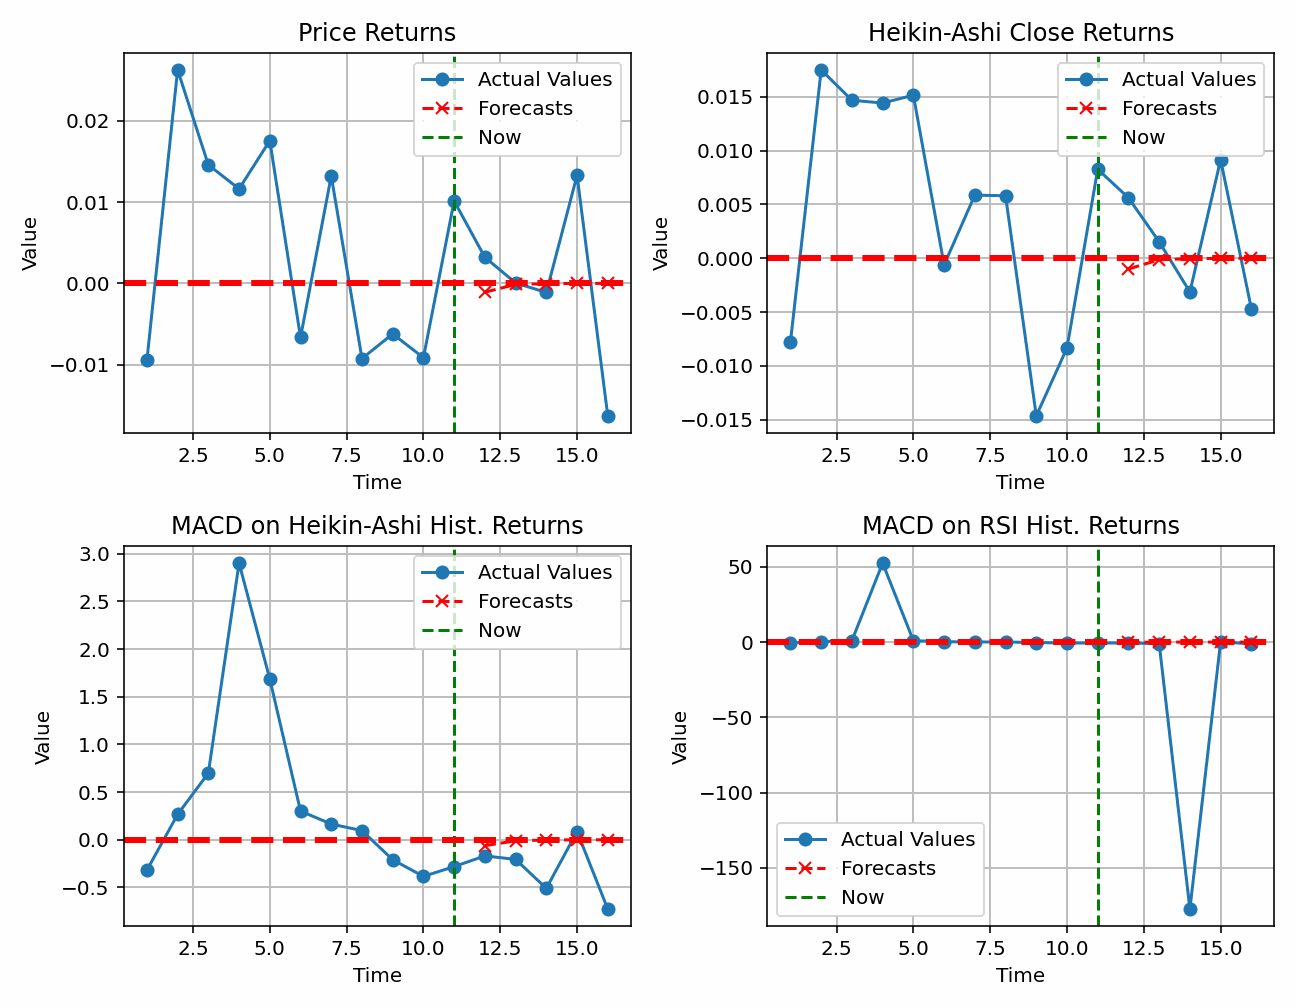

<u>__References__<u>

Content inspired by course lecture notes and material in __[1]__.

__[1]__ Steven L. Brunton; J. Nathan Kutz (2019). "Data Driven Science and Engineering: Machine Learning, Dynamical Systems, and Control". Section 3.7.

__[2]__ M. Gavish and D. L. Donoho, "The Optimal Hard Threshold for Singular Values is $4 / \sqrt{3}$" in IEEE Transactions on Information Theory, vol. 60, no. 8, pp. 5040-5053, Aug. 2014, doi: 10.1109/TIT.2014.2323359.